# Per-scale vs per-outcome variance design in mfsusieR

## Context

A DWT-packed response matrix `D[[m]]` has `T_basis[m]` columns: `T_basis[m] - 1`
detail (wavelet) coefficients arranged by scale, followed by one smoothing
coefficient.  The detail coefficients at different scales have different
characteristic magnitudes: coarse-scale coefficients tend to be larger and
smoother, fine-scale ones smaller and noisier.

Two key variance parameters can be either shared across all wavelet columns
within a modality (`"per_outcome"`) or split one-per-scale (`"per_scale"`):

| Parameter | `"per_outcome"` | `"per_scale"` |
|---|---|---|
| `residual_variance_scope` | one $\sigma^2_m$ scalar | one $\sigma^2_{m,s}$ per wavelet scale |
| `prior_variance_scope` | one $K$-component mixture per modality | one $K$-component mixture per wavelet scale |

The original `fsusie` (Denault et al.) uses a single $\sigma^2$ per modality
(`"per_outcome"`).  mfsusieR implements both modes; `"per_outcome"` is the
default for `residual_variance_scope`, `"per_outcome"` is also the default for
`prior_variance_scope`.

---

## 1. The wavelet scale index

### What `scale_index` stores

**File:** `R/dwt.R`, via `gen_wavelet_indx` in `R/utils_wavelet.R`.

For a signal of length $T = 2^J$, the DWT packs detail coefficients
level-by-level into columns `1` through `T - 1`, then the smoothing
coefficient in column `T`.  `gen_wavelet_indx(J)` returns a list of $J + 1$
integer vectors giving the column indices that belong to each scale (level 0
through level $J - 1$, plus the smoothing coefficient as level $J$).

In [1]:
suppressPackageStartupMessages(library(mfsusieR))

# For T = 32 = 2^5: 5 detail levels + 1 smoothing level = 6 groups
idx <- mfsusieR:::gen_wavelet_indx(5L)
cat(sprintf("T = 32 -> %d scale groups\n", length(idx)))
for (s in seq_along(idx)) {
  cat(sprintf("  scale group %d: columns %s  (%d coefs)\n",
              s, paste(idx[[s]], collapse = " "), length(idx[[s]])))
}

T = 32 -> 6 scale groups
  scale group 1: columns 31  (1 coefs)
  scale group 2: columns 29 30  (2 coefs)
  scale group 3: columns 25 26 27 28  (4 coefs)
  scale group 4: columns 17 18 19 20 21 22 23 24  (8 coefs)
  scale group 5: columns 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16  (16 coefs)
  scale group 6: columns 32  (1 coefs)


### Visual: column layout of the DWT-packed matrix

Each row is one wavelet scale.  Scale 1 (finest, 16 coefs) is at the bottom; scale 6 (smoothing, 1 coef) is at the top.

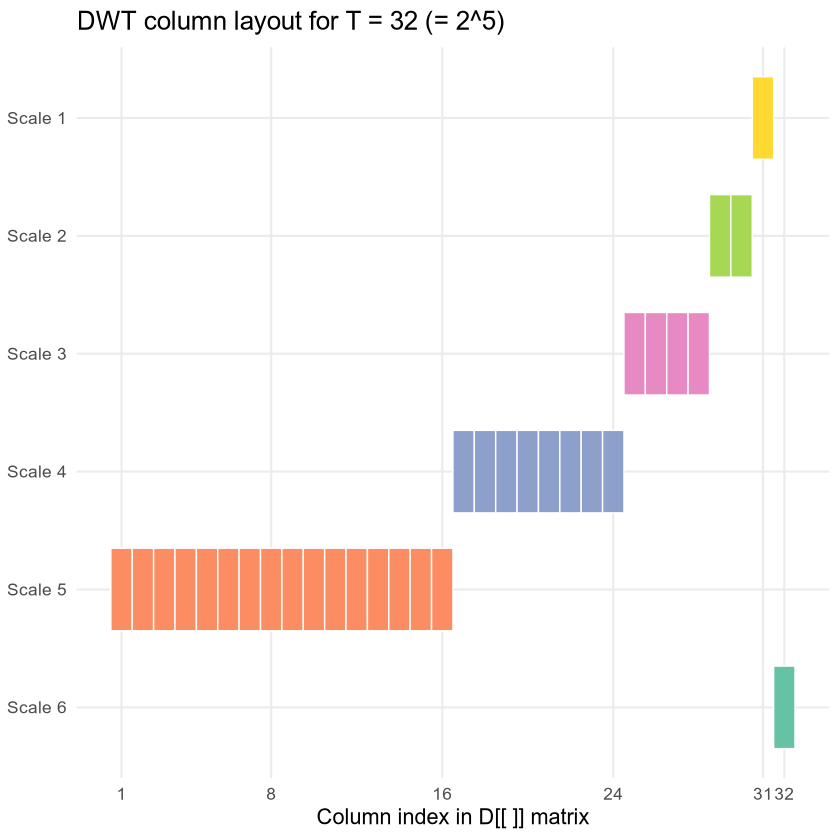

In [2]:

# ── Visual: wavelet scale-index layout for T = 32 ────────────────────────────
library(ggplot2)

idx <- mfsusieR:::gen_wavelet_indx(5L)
scale_df <- do.call(rbind, lapply(seq_along(idx), function(s) {
  data.frame(col = idx[[s]], scale = paste0("Scale ", s))
}))
scale_df$scale <- factor(scale_df$scale,
                          levels = paste0("Scale ", rev(seq_along(idx))))

ggplot(scale_df, aes(x = col, y = scale, fill = scale)) +
  geom_tile(colour = "white", linewidth = 0.4, height = 0.7) +
  scale_fill_brewer(palette = "Set2", guide = "none") +
  scale_x_continuous(breaks = c(1, 8, 16, 24, 31, 32)) +
  labs(title = "DWT column layout for T = 32 (= 2^5)",
       x = "Column index in D[[ ]] matrix", y = NULL) +
  theme_minimal(base_size = 13) +
  theme(panel.grid.minor = element_blank())


Scale group 1 (finest level) has 16 columns; each coarser level halves the
count.  The last entry (`idx[[6]]`) is a single column — the smoothing
coefficient.

### How `scale_index` is attached to the data object

`create_mf_individual` stores `data$scale_index[[m]]` per modality.  For a
scalar outcome (`T_basis[m] == 1`) `scale_index[[m]]` is `list(1L)` — a single
group containing the one column.

In [3]:
set.seed(1)
n <- 60L; p <- 40L; T1 <- 32L; T2 <- 64L
X  <- matrix(rnorm(n * p), n, p)
Y1 <- matrix(rnorm(n * T1), n, T1)
Y2 <- matrix(rnorm(n * T2), n, T2)

data_obj <- mfsusieR:::create_mf_individual(
  X = X, Y = list(Y1, Y2),
  pos = list(seq_len(T1), seq_len(T2))
)

cat("T_basis: ", data_obj$T_basis, "\n")
cat("Number of scale groups, modality 1:", length(data_obj$scale_index[[1]]), "\n")
cat("Number of scale groups, modality 2:", length(data_obj$scale_index[[2]]), "\n")
cat("Columns per group, modality 1:",
    sapply(data_obj$scale_index[[1]], length), "\n")

T_basis:  32 64 
Number of scale groups, modality 1: 6 
Number of scale groups, modality 2: 7 
Columns per group, modality 1: 1 2 4 8 16 1 


---

## 2. `residual_variance_scope`

### What it controls

**File:** `R/individual_data_methods.R`, `update_variance_components.mf_individual` (line 436).

```r
update_variance_components.mf_individual <- function(data, params, model, ...) {
  method <- params$residual_variance_scope %||% "per_scale"
  for (m in seq_len(data$M)) {
    er2_t <- mf_get_ER2_per_position(data, model, m)   # length T_basis[m]
    n     <- length(data$na_idx[[m]])
    if (method == "per_outcome") {
      model$sigma2[[m]] <- sum(er2_t) / (n * data$T_basis[m])     # scalar
    } else {  # "per_scale"
      indx_m <- data$scale_index[[m]]
      sigma2_per_scale <- vapply(indx_m, function(idx) {
        sum(er2_t[idx]) / (n * length(idx))                        # one per scale
      }, numeric(1))
      model$sigma2[[m]] <- sigma2_per_scale                        # length S_m
    }
  }
  refresh_iter_cache.mf_individual(data, model)
}
```

`mf_get_ER2_per_position` returns the per-column expected residual sum of
squares $\widehat{ER^2}[t]$ (length `T_basis[m]`).  Under `"per_outcome"` this
is averaged over all $T$ columns; under `"per_scale"` it is averaged within
each group of columns sharing a wavelet scale.

**Broadcast to per-position** (`mf_sigma2_per_position`, line 100):

```r
mf_sigma2_per_position <- function(data, model, m) {
  sigma2_m <- model$sigma2[[m]]
  T_pad    <- data$T_basis[m]
  if (length(sigma2_m) == 1L) {        # per_outcome: broadcast scalar
    rep(sigma2_m, T_pad)
  } else {                             # per_scale: fill by index group
    v <- numeric(T_pad)
    for (s in seq_along(sigma2_m))
      v[data$scale_index[[m]][[s]]] <- sigma2_m[s]
    v
  }
}
```

Every downstream consumer of $\sigma^2$ (`shat2`, `SER_posterior_e_loglik`,
`compute_kl`, `Eloglik`) calls `mf_sigma2_per_position` and sees a length-`T_basis[m]`
vector regardless of which scope is active.

### MWE: inspect `sigma2` shape after fitting

In [4]:
set.seed(42)
n <- 80L; p <- 50L; T1 <- 32L
X <- matrix(rnorm(n * p), n, p)
beta <- numeric(p); beta[5] <- 3
signal <- as.numeric(X %*% beta)
Y1 <- matrix(rnorm(n * T1, sd = 0.8), n, T1) + signal

fit_po <- mfsusie(X, list(Y1), pos = list(seq_len(T1)),
                  L = 3L, max_iter = 15L,
                  residual_variance_scope = "per_outcome",
                  verbose = FALSE)

fit_ps <- mfsusie(X, list(Y1), pos = list(seq_len(T1)),
                  L = 3L, max_iter = 15L,
                  residual_variance_scope = "per_scale",
                  verbose = FALSE)

cat("per_outcome: sigma2[[1]] length =", length(fit_po$sigma2[[1]]),
    " value =", round(fit_po$sigma2[[1]], 4), "\n")

cat("per_scale:   sigma2[[1]] length =", length(fit_ps$sigma2[[1]]),
    "\n  values:", round(fit_ps$sigma2[[1]], 4), "\n")
cat("  (groups: finest -> coarsest -> smoothing)\n")

# Scale group sizes for reference
cat("  scale group sizes:",
    sapply(data_obj$scale_index[[1]], length), "\n")

per_outcome: sigma2[[1]] length = 1  value = 0.9571 
per_scale:   sigma2[[1]] length = 6 
  values: 0.9875 0.9875 0.9875 0.9875 0.9875 0.0148 
  (groups: finest -> coarsest -> smoothing)
  scale group sizes: 1 2 4 8 16 1 


### Visual: per-scale sigma2 values

Bars show $\hat\sigma^2$ per wavelet scale (per_scale mode).  The dashed red line is the single per_outcome estimate.  Bar colour encodes the number of coefficients in that scale group.

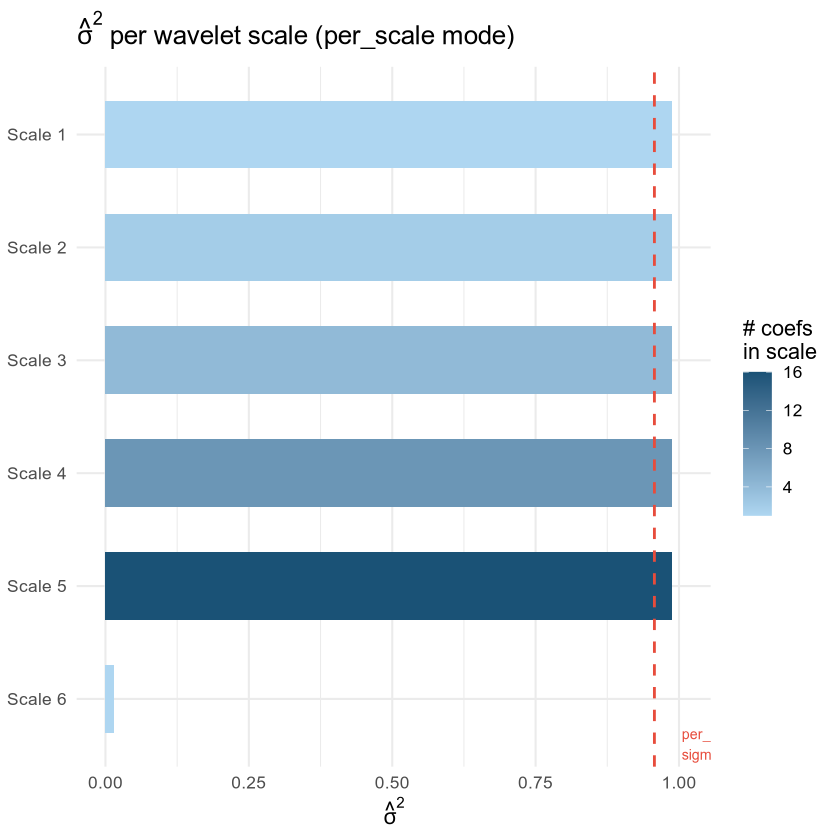

In [5]:

# ── Visual: per-scale sigma2 values (bar chart) ───────────────────────────────
library(ggplot2)

idx    <- mfsusieR:::gen_wavelet_indx(5L)
sz_df  <- data.frame(
  scale     = paste0("Scale ", seq_along(idx)),
  n_coefs   = sapply(idx, length),
  sigma2_ps = fit_ps$sigma2[[1]]
)
sz_df$scale <- factor(sz_df$scale, levels = rev(sz_df$scale))

ggplot(sz_df, aes(x = scale, y = sigma2_ps, fill = n_coefs)) +
  geom_col(width = 0.6) +
  geom_hline(yintercept = fit_po$sigma2[[1]], linetype = "dashed",
             colour = "#e74c3c", linewidth = 0.8) +
  annotate("text", x = 0.6, y = fit_po$sigma2[[1]] * 1.05,
           label = sprintf("per_outcome\nsigma2 = %.3f", fit_po$sigma2[[1]]),
           colour = "#e74c3c", size = 3, hjust = 0) +
  scale_fill_gradient(low = "#aed6f1", high = "#1a5276",
                      name = "# coefs\nin scale") +
  coord_flip() +
  labs(title = expression(hat(sigma)^2 ~ "per wavelet scale (per_scale mode)"),
       x = NULL, y = expression(hat(sigma)^2)) +
  theme_minimal(base_size = 13)


The `"per_scale"` vector shows that the coarser scales (groups 4-6 here)
typically have higher $\sigma^2$ per coefficient because fewer observations
constrain those averages.

---

## 3. `prior_variance_scope`

### What it controls

**File:** `R/prior_scale_mixture.R`, `mf_prior_scale_mixture` (line 250).

`prior_variance_scope` selects the prior class and the `groups_m` partition
of wavelet columns.

```r
prior_class <- switch(prior_variance_scope,
  per_outcome       = "mixture_normal",             # 1 entry in G_prior[[m]]
  per_scale         = "mixture_normal_per_scale",   # S_m entries
  per_scale_normal  = "mixture_point_normal_per_scale",    # S_m entries, ebnm
  per_scale_laplace = "mixture_point_laplace_per_scale"    # S_m entries, ebnm
)

groups_m <- if (prior_variance_scope == "per_outcome") {
  list(unlist(data$scale_index[[m]]))   # one group = all columns
} else {
  data$scale_index[[m]]                 # S_m groups, one per scale
}
```

The IBSS kernels (`loglik.mf_individual`,
`calculate_posterior_moments.mf_individual`,
`optimize_prior_variance.mf_individual`) iterate over `G_prior[[m]]` and
use `G_prior[[m]][[s]]$idx` to slice the `(Bhat, Shat)` rectangle.  A
`"per_outcome"` prior has one `G_prior[[m]][[1]]` entry whose `$idx` covers
all columns; a `"per_scale"` prior has `S_m` entries, each covering one scale.
No mode-specific branching appears in the loop body — only the length of
`G_prior[[m]]` differs.

### Four prior modes

| `prior_variance_scope` | `G_prior[[m]]` length | Fit method | Parameters per (m, s) |
|---|---|---|---|
| `"per_outcome"` | 1 | mixsqp EM | $K$ mixture weights |
| `"per_scale"` | $S_m$ | mixsqp EM | $K$ mixture weights |
| `"per_scale_normal"` | $S_m$ | ebnm point-normal | $(\pi_0, \sigma^2)$ |
| `"per_scale_laplace"` | $S_m$ | ebnm point-Laplace | $(\pi_0, b)$ |

`"per_scale_normal"` and `"per_scale_laplace"` are the most parsimonious:
2 parameters per (modality, scale) instead of $K + 1$.  They are the right
choice when each wavelet scale has a single characteristic effect-size scale
and the $K + 1$-component mixsqp fit is under-constrained (typically at
coarse scales with few coefficients).

### MWE: inspect `G_prior` structure

In [6]:
fit_pvpo <- mfsusie(X, list(Y1), pos = list(seq_len(T1)),
                    L = 3L, max_iter = 1L,
                    prior_variance_scope = "per_outcome",
                    verbose = FALSE)

fit_pvps <- mfsusie(X, list(Y1), pos = list(seq_len(T1)),
                    L = 3L, max_iter = 1L,
                    prior_variance_scope = "per_scale",
                    verbose = FALSE)

fit_pvpn <- mfsusie(X, list(Y1), pos = list(seq_len(T1)),
                    L = 3L, max_iter = 1L,
                    prior_variance_scope = "per_scale_normal",
                    verbose = FALSE)

cat("per_outcome:  G_prior[[1]] length =", length(fit_pvpo$G_prior[[1]]),
    "  (1 group covers all", T1, "columns)\n")

cat("per_scale:    G_prior[[1]] length =", length(fit_pvps$G_prior[[1]]),
    "  (one entry per wavelet scale)\n")
for (s in seq_along(fit_pvps$G_prior[[1]])) {
  g <- fit_pvps$G_prior[[1]][[s]]
  cat(sprintf("  scale %d: idx[1:%d], K=%d, class=%s\n",
              s, length(g$idx), length(g$fitted_g$sd),
              class(fit_pvps$G_prior[[1]])))
}

cat("\nper_scale_normal: G_prior[[1]] length =", length(fit_pvpn$G_prior[[1]]),
    "  (ebnm point-normal per scale)\n")
for (s in seq_along(fit_pvpn$G_prior[[1]])) {
  g <- fit_pvpn$G_prior[[1]][[s]]
  cat(sprintf("  scale %d: idx[1:%d], pi0=%.3f, sigma=%.4f\n",
              s, length(g$idx), g$fitted_g$pi[1],
              g$fitted_g$sd[2]))
}


Warning message:
“IBSS algorithm did not converge in 1 iterations!”

Warning message:
“IBSS algorithm did not converge in 1 iterations!”

Warning message:
“IBSS algorithm did not converge in 1 iterations!”


per_outcome:  G_prior[[1]] length = 1   (1 group covers all 32 columns)
per_scale:    G_prior[[1]] length = 6   (one entry per wavelet scale)
  scale 1: idx[1:1], K=17, class=mixture_normal_per_scale
  scale 2: idx[1:2], K=17, class=mixture_normal_per_scale
  scale 3: idx[1:4], K=17, class=mixture_normal_per_scale
  scale 4: idx[1:8], K=17, class=mixture_normal_per_scale
  scale 5: idx[1:16], K=17, class=mixture_normal_per_scale
  scale 6: idx[1:1], K=17, class=mixture_normal_per_scale

per_scale_normal: G_prior[[1]] length = 6   (ebnm point-normal per scale)
  scale 1: idx[1:1], pi0=0.000, sigma=0.0518
  scale 2: idx[1:2], pi0=1.000, sigma=1.0000
  scale 3: idx[1:4], pi0=0.000, sigma=0.0212
  scale 4: idx[1:8], pi0=0.000, sigma=0.0373
  scale 5: idx[1:16], pi0=1.000, sigma=1.0000
  scale 6: idx[1:1], pi0=1.000, sigma=1.0000


### Visual: mixture weights per scale (per_scale prior)

Each facet is one wavelet scale.  The x-axis shows the mixture SD components; the y-axis shows the fitted $\pi_k$ weight after the IBSS EM step.

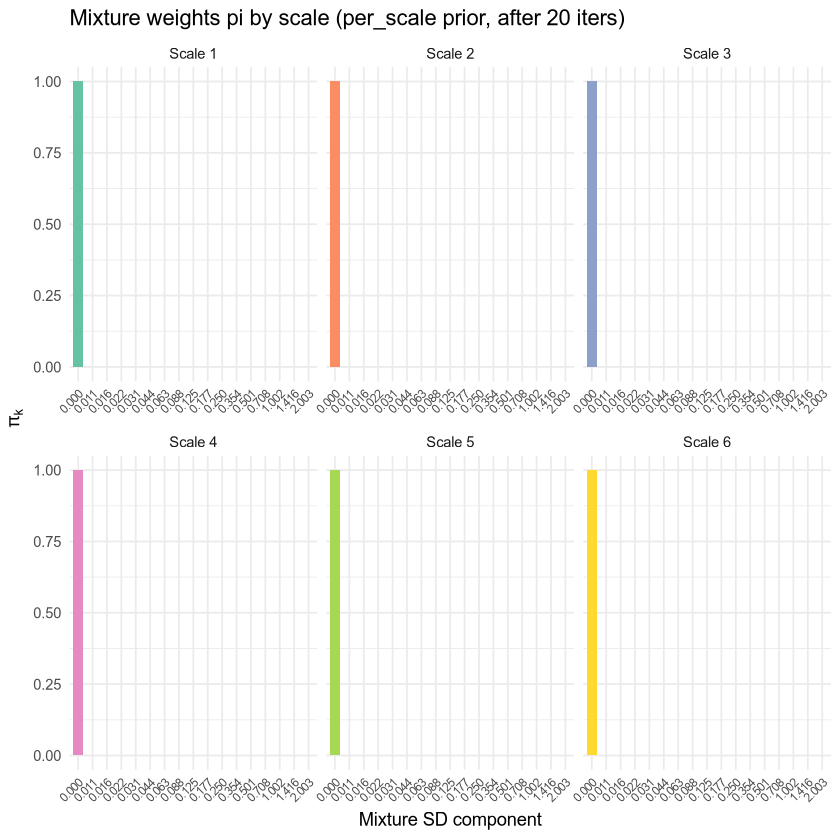

In [7]:

# ── Visual: G_prior mixture weights per scale (per_scale mode) ────────────────
library(ggplot2)

# Extract pi (mixture weights) for each scale group after fitting
g_list <- fit_pvps$G_prior[[1]]
pi_df  <- do.call(rbind, lapply(seq_along(g_list), function(s) {
  pi_vec <- g_list[[s]]$fitted_g$pi
  sd_vec <- g_list[[s]]$fitted_g$sd
  data.frame(scale = paste0("Scale ", s),
             component = seq_along(pi_vec),
             sd        = round(sd_vec, 4),
             pi        = pi_vec)
}))
pi_df$scale <- factor(pi_df$scale,
                       levels = paste0("Scale ", seq_along(g_list)))
pi_df$label <- sprintf("%.3f", pi_df$sd)

ggplot(pi_df, aes(x = label, y = pi, fill = scale)) +
  geom_col(width = 0.7) +
  facet_wrap(~scale, scales = "free_x", ncol = 3) +
  scale_fill_brewer(palette = "Set2", guide = "none") +
  labs(title = "Mixture weights pi by scale (per_scale prior, after 20 iters)",
       x = "Mixture SD component", y = expression(pi[k])) +
  theme_minimal(base_size = 11) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1, size = 7))


---

## 4. How the two scopes interact

`residual_variance_scope` and `prior_variance_scope` are orthogonal: all four
combinations are valid.

| | `residual_variance_scope = "per_outcome"` | `residual_variance_scope = "per_scale"` |
|---|---|---|
| `prior_variance_scope = "per_outcome"` | fsusie default | per-scale $\sigma^2$, shared prior |
| `prior_variance_scope = "per_scale"` | shared $\sigma^2$, per-scale prior | most parameters |

The original `fsusie` is equivalent to `residual_variance_scope = "per_outcome"` +
`prior_variance_scope = "per_outcome"`.  William's suggestion to try per-scale
variance parameters corresponds to `residual_variance_scope = "per_scale"` +
`prior_variance_scope = "per_scale"`.

### MWE: compare ELBO and PIP recovery across mode combinations

In [8]:
combos <- list(
  "rvo+pvo" = list(residual_variance_scope = "per_outcome",
                   prior_variance_scope    = "per_outcome"),
  "rvs+pvo" = list(residual_variance_scope = "per_scale",
                   prior_variance_scope    = "per_outcome"),
  "rvo+pvs" = list(residual_variance_scope = "per_outcome",
                   prior_variance_scope    = "per_scale"),
  "rvs+pvs" = list(residual_variance_scope = "per_scale",
                   prior_variance_scope    = "per_scale")
)

results <- lapply(names(combos), function(nm) {
  args <- c(
    list(X = X, Y = list(Y1), pos = list(seq_len(T1)),
         L = 3L, max_iter = 20L, verbose = FALSE),
    combos[[nm]]
  )
  fit <- do.call(mfsusie, args)
  data.frame(
    combo     = nm,
    pip_true  = round(fit$pip[5], 3),
    elbo_last = round(tail(fit$elbo[!is.na(fit$elbo)], 1), 2),
    niter     = fit$niter,
    converged = fit$converged
  )
})
do.call(rbind, results)

combo,pip_true,elbo_last,niter,converged
<chr>,<dbl>,<dbl>,<int>,<lgl>
rvo+pvo,1,-3586.79,2,TRUE
rvs+pvo,1,-3427.63,2,TRUE
rvo+pvs,1,-3580.11,4,TRUE
rvs+pvs,1,-3381.27,4,TRUE


### Visual: PIP and ELBO across all four scope combinations

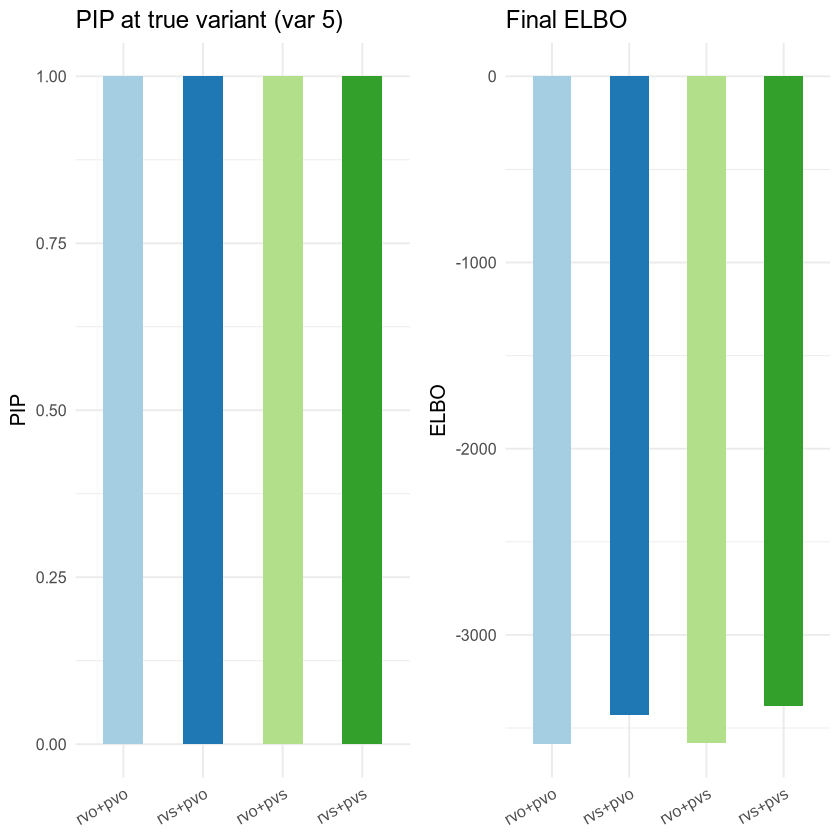

In [9]:

# ── Visual: PIP and ELBO across 4 scope combinations ─────────────────────────
library(ggplot2)

res_df <- do.call(rbind, results)
res_df$combo <- factor(res_df$combo, levels = res_df$combo)

p1 <- ggplot(res_df, aes(x = combo, y = pip_true, fill = combo)) +
  geom_col(width = 0.5) +
  scale_fill_brewer(palette = "Paired", guide = "none") +
  ylim(0, 1) +
  labs(title = "PIP at true variant (var 5)", x = NULL, y = "PIP") +
  theme_minimal(base_size = 12) +
  theme(axis.text.x = element_text(angle = 30, hjust = 1))

p2 <- ggplot(res_df, aes(x = combo, y = elbo_last, fill = combo)) +
  geom_col(width = 0.5) +
  scale_fill_brewer(palette = "Paired", guide = "none") +
  labs(title = "Final ELBO", x = NULL, y = "ELBO") +
  theme_minimal(base_size = 12) +
  theme(axis.text.x = element_text(angle = 30, hjust = 1))

gridExtra::grid.arrange(p1, p2, ncol = 2)


---

## 5. Summary

| Field / parameter | Where set | Shape | Consumed by |
|---|---|---|---|
| `data$scale_index[[m]]` | `R/dwt.R` via `gen_wavelet_indx` | list of $S_m$ index vectors | `update_variance_components`, `mf_prior_scale_mixture`, `optimize_prior_variance` |
| `model$sigma2[[m]]` | `update_variance_components` | scalar (`per_outcome`) or length-$S_m$ (`per_scale`) | `mf_sigma2_per_position`, which broadcasts to length `T_basis[m]` for all downstream consumers |
| `model$G_prior[[m]]` | `mf_prior_scale_mixture` | list of 1 (`per_outcome`) or $S_m$ (`per_scale*`) prior records | `loglik`, `calculate_posterior_moments`, `optimize_prior_variance` — iterate over `G_prior[[m]][[s]]$idx` uniformly |

The design decouples the two variance parameters: `residual_variance_scope`
controls how many $\sigma^2$ scalars are estimated per modality;
`prior_variance_scope` controls the granularity of the effect-size prior.
Both funnel into `mf_sigma2_per_position` and the `G_prior[[m]][[s]]$idx`
loop, so the downstream IBSS code has no mode-specific branches.

**Trade-off (per William Denault's comment, 2026-05-17):** Adding more
variance parameters per scale can gain power but may also hurt FDR calibration
due to overfitting, particularly at coarse scales where the coefficient count
is small.  The `per_scale_normal` / `per_scale_laplace` modes mitigate this by
using only 2 parameters per (modality, scale) instead of $K + 1$.